# M2A10 - Modelos Pré-Treinados

Na prática de hoje vamos utilizar modelos de aprendizado profundo pré-treinados, e para isso vamos utilizar [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Modelos Pré-treinados
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [8]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


Importar as bibliotecas e Ler Imagens do Disco

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision
from PIL import Image

In [5]:
# TODO Atualize o path da imagem.
image = cv2.imread("./dog2.jpeg")

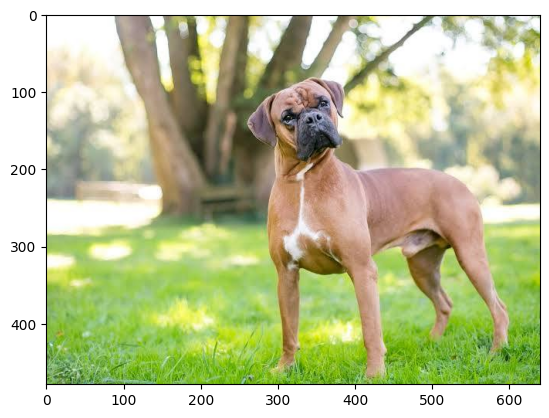

In [6]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Modelos Pré-Treinados

A primeira coisa para utilizar modelos pré-treinados é carregar seus pesos pré-treinados, utilizamos a biblioteca PyTorch para isso.

In [10]:
# Definindo os pesos a serem utilizados.
weights = torchvision.models.VGG16_Weights.DEFAULT

# Carregar os labels do dataset.
imagenet_labels = weights.meta["categories"] 

# Carregar o modelo.
vgg_16_model = torchvision.models.vgg16(weights)

# Criando o pipeline de transformações de pré-processamento dos dados.
preprocess = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

/Users/joseph-cbp/Documents/Visão Computacional/.venv/lib/python3.14/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [8]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Pré processando a imagem.
image_tensor = preprocess(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
input_batch = image_tensor.unsqueeze(0) 


In [9]:
# Escolhendo o dispositivo a ser utilizado GPU se disponível.
if torch.cuda.is_available():
    input_batch = input_batch.to('cuda')
    vgg_16_model.to('cuda')

# Rodando a inferência.
with torch.no_grad():
    output = vgg_16_model(input_batch)

# Calculando as probabilidades das classes.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

Classe predita para imagem: boxer


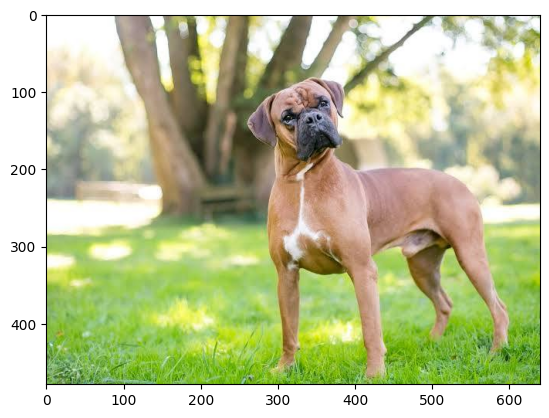

In [13]:
# Validando a classe prevista.
print(f"Classe predita para imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'French bulldog'),
  Text(1, 0, 'vizsla'),
  Text(2, 0, 'redbone'),
  Text(3, 0, 'Brabancon griffon'),
  Text(4, 0, 'Great Dane'),
  Text(5, 0, 'American Staffordshire terrier'),
  Text(6, 0, 'Staffordshire bullterrier'),
  Text(7, 0, 'Rhodesian ridgeback'),
  Text(8, 0, 'bull mastiff'),
  Text(9, 0, 'boxer')])

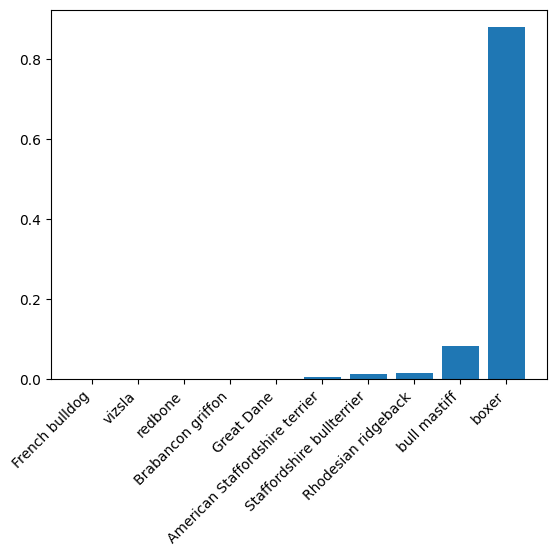

In [14]:
# Criar conjunto de labels e probabilidades, e ordenar.
set_labels_probs = list(zip(imagenet_labels, list(probabilities.cpu().numpy())))
set_labels_probs = sorted(set_labels_probs, key=lambda x: x[1])

# Pega as N classes mais prováveis.
num = 10
most_probable_classes = set_labels_probs[-num:]

# Criar as listas para o plot.
labels, probs = zip(*most_probable_classes)

# Observando as probabilidades.
plt.bar(labels, probs)
plt.xticks(rotation=45, ha='right') # Rotate labels by 45 degrees and align right


E assim terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas iremo avançar ainda mais no mundo de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [ ] Rode a inferência com outra imagem.
- [ ] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.

In [18]:
def run_inference(image_bgr, preprocess, model, device):
    # image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    print(type(image))

    print(image.shape)

    print(image.dtype)

    print(preprocess)
    image_tensor = preprocess(image)
   
    input_batch = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)
    
    probabilities = torch.nn.functional.softmax(output[0], dim=0)
    print(f"Classe predita para a imagem: {imagenet_labels[torch.argmax(probabilities)]}")
    plt.imshow(image)


Classe predita para a imagem: boxer


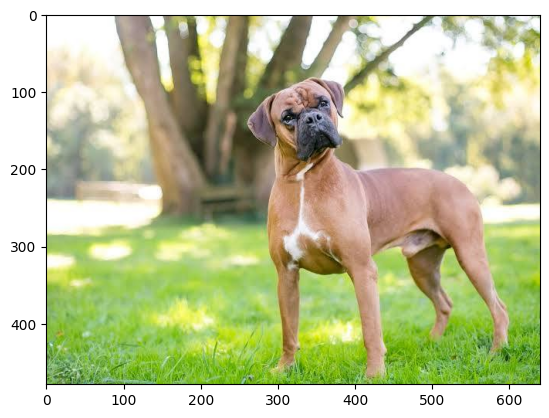

In [28]:
image = cv2.imread("./dog2.jpeg")
pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

weights_resnet = torchvision.models.ResNet50_Weights.DEFAULT
main_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet50 = torchvision.models.resnet50(weights=weights_resnet)
resnet50 = resnet50.to(main_device)
resnet50.eval()
preprocess = weights_resnet.transforms()

image_tensor = preprocess(pil_image).unsqueeze(0).to(main_device)

with torch.no_grad():
    output = resnet50(image_tensor)

probabilities = torch.nn.functional.softmax(output[0], dim = 0)
print(f"Classe predita para a imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(pil_image)

Classe predita para a imagem: dalmatian


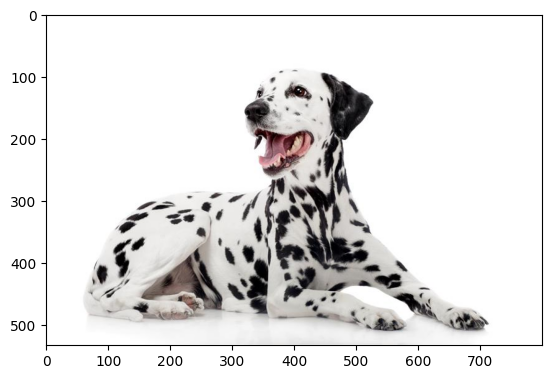

In [36]:
weights_mobile_net = torchvision.models.MobileNet_V3_Large_Weights.DEFAULT

mobile_net = torchvision.models.mobilenet_v3_large(weights = weights_mobile_net)
mobile_net.eval()
mobile_preprocess = weights_mobile_net.transforms()

image_mobile_net = cv2.imread("./dog.jpeg")
image_mobile_net = Image.fromarray(cv2.cvtColor(image_mobile_net , cv2.COLOR_BGR2RGB))
image_mobile_tensor = mobile_preprocess(image_mobile_net).unsqueeze(0)

with torch.no_grad():
    output = mobile_net(image_mobile_tensor)

probabilities = torch.nn.functional.softmax(output[0], dim= 0)
print(f"Classe predita para a imagem: {imagenet_labels[torch.argmax(probabilities)]}")
plt.imshow(image_mobile_net)
